In [2]:
import xarray as xr
import rioxarray as riox
from hlsstack.hls_funcs.predict import xr_cdf

In [3]:
from rasterio.plot import show

In [4]:
ds = riox.open_rasterio('/90daydata/cper_neon_aop/hls_nrt/gcloud/hls_cper_2024_gcloud.nc')

In [7]:
bm_se = riox.open_rasterio('/90daydata/cper_neon_aop/hls_nrt/cper/hls_biomass/cper_hls_bm_se_2024.nc')

In [10]:
ds_sel = ds.isel(date=150)
bm_se_sel = bm_se.isel(time=150)

In [11]:
ds_sel

<xarray.Dataset>
Dimensions:      (y: 325, x: 323)
Coordinates:
  * y            (y) float64 4.993e+06 4.993e+06 4.993e+06 ... 4.98e+06 4.98e+06
  * x            (x) float64 -1.167e+07 -1.167e+07 ... -1.165e+07 -1.165e+07
    date         object 2024-05-30 00:00:00
    spatial_ref  int64 0
Data variables:
    BARE         (y, x) float32 ...
    GREEN        (y, x) float32 ...
    SD           (y, x) float32 ...
    LITT         (y, x) float32 ...
    Biomass      (y, x) float32 ...
    Biomass_SE   (y, x) float32 ...
    NDVI         (y, x) float32 ...
    DRYVEG       (y, x) float32 ...
    NONVEG       (y, x) float32 ...
Attributes:
    _FillValue:  3.402823466385289e+38

/project/cper_neon_aop/conda_envs/hls_nrt_env/lib/python3.9/site-packages/matplotlib/image.py:503: RuntimeWarning: overflow encountered in multiply
  A_resampled *= ((a_max - a_min) / frac)


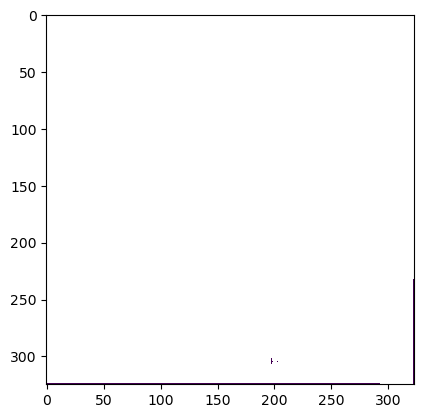

<AxesSubplot:>

In [17]:
show(ds_sel['Biomass_SE'].data, vmin=0, vmax=250)

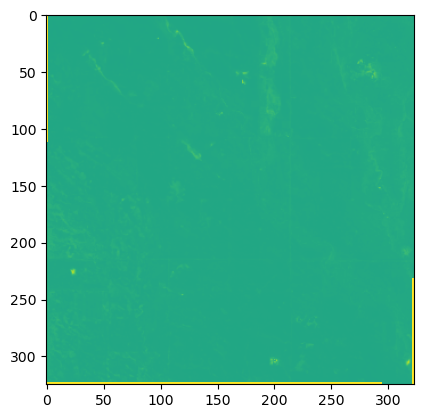

<AxesSubplot:>

In [16]:
show(bm_se_sel.data, vmin=0, vmax=250)

In [14]:
bm_se_sel.max()

<xarray.DataArray 'Biomass_SE' ()>
array(3.4028235e+38, dtype=float32)
Coordinates:
    time         object 2024-05-30 00:00:00
    spatial_ref  int64 0

In [27]:
ds_sel['Biomass_SE'].max()

<xarray.DataArray 'Biomass_SE' ()>
array(inf, dtype=float32)
Coordinates:
    date         object 2024-05-30 00:00:00
    spatial_ref  int64 0

In [20]:
da_thresh_pre = (400 - ds_sel['Biomass']) / ds_sel['Biomass_SE']
da_thresh = xr_cdf(da_thresh_pre)

In [21]:
da_thresh

<xarray.DataArray (y: 325, x: 323)>
array([[0.15865525, 0.5       , 0.5       , ..., 0.15865525, 0.15865525,
        0.15865525],
       [0.15865525, 0.5       , 0.5       , ..., 0.5       , 0.5       ,
        0.5       ],
       [0.15865525, 0.5       , 0.5       , ..., 0.5       , 0.5       ,
        0.5       ],
       ...,
       [0.5       , 0.5       , 0.5       , ..., 0.5       , 0.5       ,
        0.15865525],
       [0.5       , 0.5       , 0.5       , ..., 0.5       , 0.5       ,
        0.15865525],
       [0.15865525, 0.15865525, 0.15865525, ..., 0.5       , 0.5       ,
        0.15865525]])
Coordinates:
  * y            (y) float64 4.993e+06 4.993e+06 4.993e+06 ... 4.98e+06 4.98e+06
  * x            (x) float64 -1.167e+07 -1.167e+07 ... -1.165e+07 -1.165e+07
    date         object 2024-05-30 00:00:00
    spatial_ref  int64 0

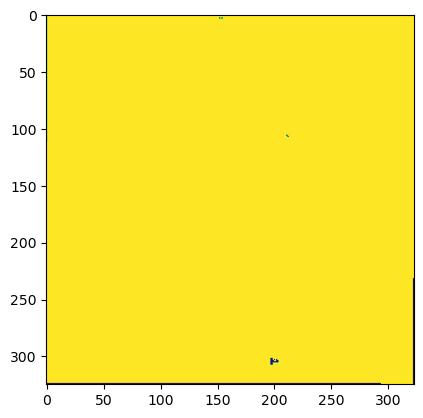

<AxesSubplot:>

In [22]:
show(da_thresh)

In [16]:
da_thresh.max()

<xarray.DataArray ()>
array(0.5)
Coordinates:
    date         object 2024-12-31 00:00:00
    spatial_ref  int64 0

In [34]:
from hlsstack.hls_funcs.predict import pred_bm, pred_bm_se, pred_cov
from hlsstack.models.load import load_model
from sklearn.exceptions import InconsistentVersionWarning

In [31]:
hls_ds = xr.open_dataset('/90daydata/cper_neon_aop/hls_nrt/cper/cper_hls_tmp/hls_ds_2024_20250205.nc')

In [35]:
print('   computing biomass SE for available dates...')
mod_boot_d = '/project/cper_neon_aop/cper_hls_veg_models/models/biomass/cper_bm_pls_boot'
#warnings.filterwarnings('ignore', category=InconsistentVersionWarning)
mod_bm = load_model('cper_biomass')
# create biomass SE array
xr_bm_se = ds.map_blocks(pred_bm_se, template=hls_ds['NIR1'],
                          kwargs=dict(model=mod_bm,
                                     mod_boot_dir=mod_boot_d,
                                     nboot=100)).where(ds['NIR1'].notnull())#.compute()
xr_bm_se.name = 'Biomass_SE'

   computing biomass SE for available dates...


KeyboardInterrupt: 